In [347]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy.stats import ttest_ind
from scipy.stats import linregress
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

In [2]:
data = pd.read_csv("C:/Users/Durosimi/PROJECTS/Match_Predictor/data/processed/cleaned.csv")

In [3]:
data.head()

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,AHCh,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season
0,E0,2022-08-05,20:00,Crystal Palace,Arsenal,0,2,A,0,1,...,0.50,2.09,1.84,2.04,1.88,2.09,1.88,2.03,1.85,2022/2023
1,E0,2022-08-06,12:30,Fulham,Liverpool,2,2,D,1,0,...,1.75,1.90,2.03,1.91,2.02,2.01,2.06,1.89,1.99,2022/2023
2,E0,2022-08-06,15:00,Bournemouth,Aston Villa,2,0,H,1,0,...,0.50,1.93,2.00,1.93,2.00,1.94,2.04,1.88,2.00,2022/2023
3,E0,2022-08-06,15:00,Leeds,Wolves,2,1,H,1,1,...,-0.25,2.08,1.85,2.10,1.84,2.14,1.87,2.08,1.81,2022/2023
4,E0,2022-08-06,15:00,Newcastle,Nott'm Forest,2,0,H,0,0,...,-1.00,1.97,1.96,1.99,1.93,2.19,1.97,2.03,1.86,2022/2023


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 89 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Div        1520 non-null   object 
 1   Date       1520 non-null   object 
 2   Time       1520 non-null   object 
 3   HomeTeam   1520 non-null   object 
 4   AwayTeam   1520 non-null   object 
 5   FTHG       1520 non-null   int64  
 6   FTAG       1520 non-null   int64  
 7   FTR        1520 non-null   object 
 8   HTHG       1520 non-null   int64  
 9   HTAG       1520 non-null   int64  
 10  HTR        1520 non-null   object 
 11  Referee    1520 non-null   object 
 12  HS         1520 non-null   int64  
 13  AS         1520 non-null   int64  
 14  HST        1520 non-null   int64  
 15  AST        1520 non-null   int64  
 16  HF         1520 non-null   int64  
 17  AF         1520 non-null   int64  
 18  HC         1520 non-null   int64  
 19  AC         1520 non-null   int64  
 20  HY      

In [5]:
data['HomeTeam'].unique()

array(['Crystal Palace', 'Fulham', 'Bournemouth', 'Leeds', 'Newcastle',
       'Tottenham', 'Everton', 'Leicester', 'Man United', 'West Ham',
       'Brentford', 'Wolves', 'Southampton', 'Arsenal', 'Brighton',
       'Aston Villa', 'Man City', "Nott'm Forest", 'Chelsea', 'Liverpool',
       'Burnley', 'Sheffield United', 'Luton', 'Ipswich', 'Sunderland'],
      dtype=object)

In [6]:
data['Season'].unique()

array(['2022/2023', '2023/2024', '2024/2025', '2025/2026'], dtype=object)

In [7]:
data['Season'].value_counts()

Season
2022/2023    380
2023/2024    380
2024/2025    380
2025/2026    380
Name: count, dtype: int64

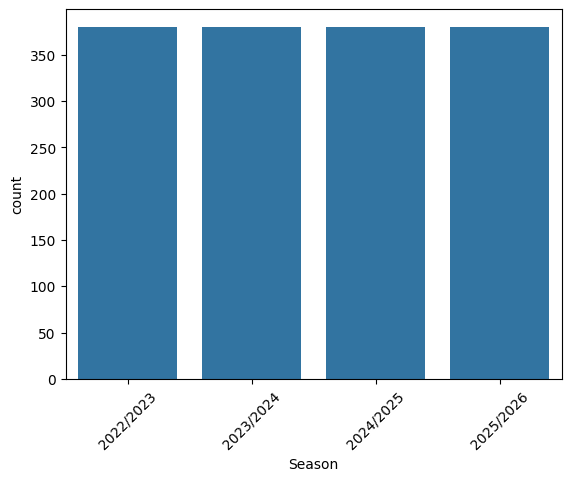

In [8]:
sns.countplot(
    data=data,
    x="Season"
)

plt.xticks(rotation=45)
plt.show()

#### Checking to see the distribution for wins, losses and draws

In [10]:
data['FTR'].value_counts()

FTR
H    676
A    478
D    366
Name: count, dtype: int64

#### Checking the percentage for wins, losses and draws

In [12]:
season_win = pd.crosstab(data['Season'], data['FTR'], normalize='index')*100

In [13]:
season_win

FTR,A,D,H
Season,,,
2022/2023,28.684211,22.894737,48.421053
2023/2024,32.368421,21.578947,46.052632
2024/2025,34.736842,24.473684,40.789474
2025/2026,30.000000,27.368421,42.631579


<Figure size 600x600 with 0 Axes>

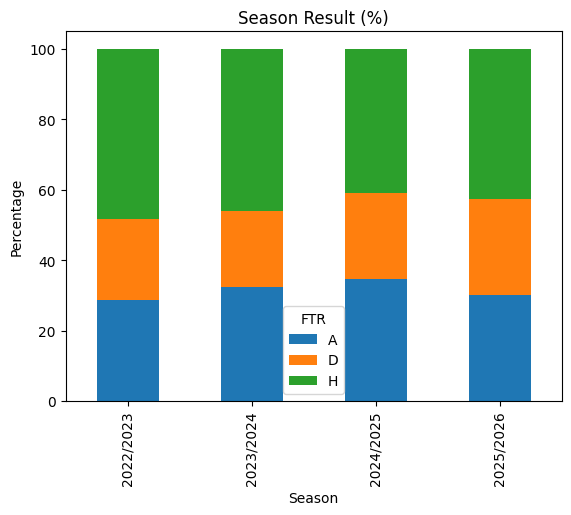

In [14]:
plt.figure(figsize=(6,6))
season_win.plot(kind='bar', stacked=True)
plt.title("Season Result (%)")
plt.ylabel("Percentage")
plt.show()

In [15]:
data['FTR'].value_counts(normalize=True)*100

FTR
H    44.473684
A    31.447368
D    24.078947
Name: proportion, dtype: float64

In [16]:
rates = data['FTR'].value_counts(normalize=True)

home_win_rate = rates.get('H', 0) * 100
away_win_rate = rates.get('A', 0) * 100
draw_rate = rates.get('D', 0) * 100

print(f"Home Win Rate: {home_win_rate:.2f}%")
print(f"Away Win Rate: {away_win_rate:.2f}%")
print(f"Draw Rate: {draw_rate:.2f}%")

Home Win Rate: 44.47%
Away Win Rate: 31.45%
Draw Rate: 24.08%


In [17]:
# is_home_team
# home_advantage_score

#### Average home goals?
#### Average away goals?
#### Outliers?
#### Skewness?

In [19]:
data["FTAG"].describe()

count    1520.000000
mean        1.335526
std         1.190505
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         8.000000
Name: FTAG, dtype: float64

In [20]:
data["FTHG"].describe()

count    1520.000000
mean        1.618421
std         1.315498
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         9.000000
Name: FTHG, dtype: float64

<Axes: ylabel='FTAG'>

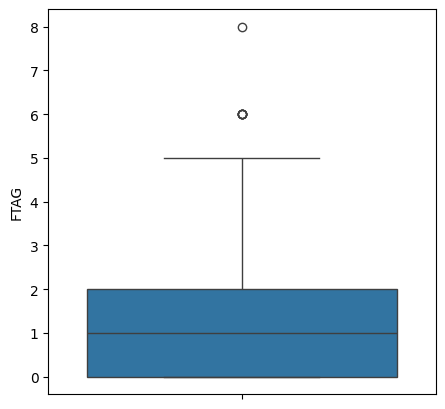

In [21]:
plt.figure(figsize=(5,5))
sns.boxplot(data, y=data['FTAG'])

<Axes: ylabel='FTHG'>

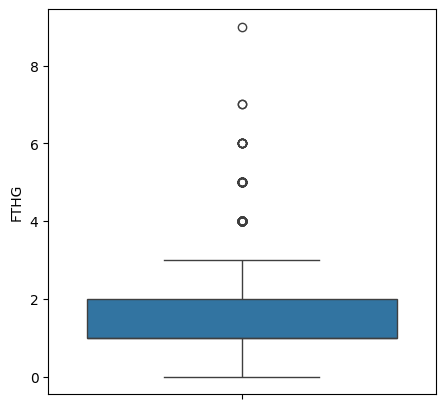

In [22]:
plt.figure(figsize=(5,5))
sns.boxplot(data, y=data['FTHG'])

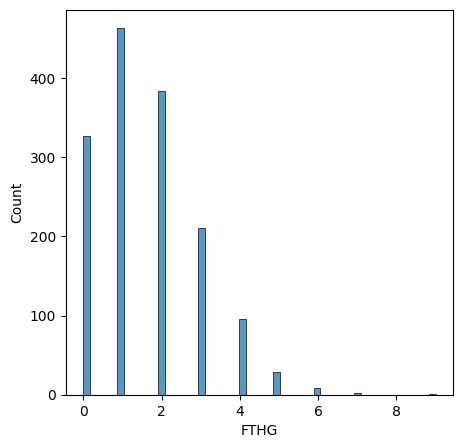

In [23]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['FTHG'])
plt.show()

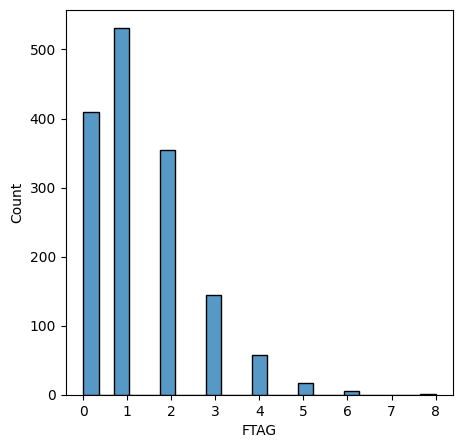

In [24]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['FTAG'])
plt.show()

##### How common are high-scoring matches?
#### Distribution?

In [26]:
data["TotalGoals"] = (
    data["FTHG"] + data["FTAG"]
)

In [27]:
data[["FTHG", "FTAG", "TotalGoals"]].head()

,FTHG,FTAG,TotalGoals
0,0,2,2
1,2,2,4
2,2,0,2
3,2,1,3
4,2,0,2


In [28]:
data["TotalGoals"].describe()

count    1520.000000
mean        2.953947
std         1.671268
min         0.000000
25%         2.000000
50%         3.000000
75%         4.000000
max         9.000000
Name: TotalGoals, dtype: float64

In [29]:
data[(data['FTAG'] == 8) | (data['FTHG'] == 9)]

,Div,Date,Time,HomeTeam,AwayTeam,FTHG,FTAG,FTR,HTHG,HTAG,...,B365CAHH,B365CAHA,PCAHH,PCAHA,MaxCAHH,MaxCAHA,AvgCAHH,AvgCAHA,Season,TotalGoals
33,E0,2022-08-27,15:00,Liverpool,Bournemouth,9,0,H,5,0,...,1.91,1.99,1.93,1.97,1.95,2.27,1.87,2.01,2022/2023,9
438,E0,2023-09-24,16:30,Sheffield United,Newcastle,0,8,A,0,3,...,1.95,1.98,1.94,1.98,2.08,1.99,1.98,1.89,2023/2024,8


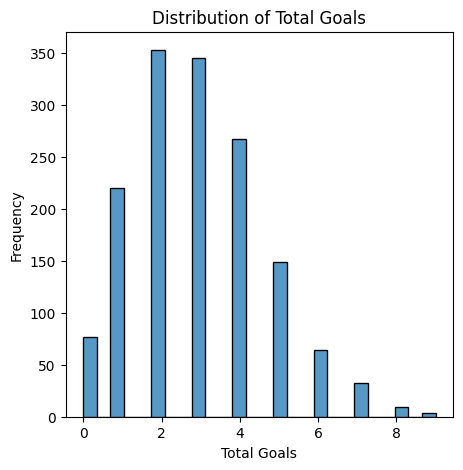

In [30]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['TotalGoals'])
plt.title("Distribution of Total Goals")
plt.xlabel("Total Goals")
plt.ylabel("Frequency")
plt.show()

Most matches have between 1 and 4 goals

In [32]:
goal_counts = (
    data["TotalGoals"]
    .value_counts()
    .sort_index()
)

print(goal_counts)

TotalGoals
0     77
1    220
2    353
3    345
4    267
5    149
6     64
7     32
8      9
9      4
Name: count, dtype: int64


In [33]:
data["Over2.5"] = (
    data["TotalGoals"] > 2
).astype(int)

In [34]:
data["Over2.5"].value_counts(normalize=True)*100

Over2.5
1    57.236842
0    42.763158
Name: proportion, dtype: float64

In [35]:
over_2_season = pd.crosstab(data['Season'], data['Over2.5'], normalize='index')*100

In [36]:
over_2_season

Over2.5,0,1
Season,,
2022/2023,47.368421,52.631579
2023/2024,35.263158,64.736842
2024/2025,43.421053,56.578947
2025/2026,45.000000,55.000000


Based on the cross tabulation done above, it can be seen that the season 2023/2024 has the highest percentage for 3 goals and above

In [180]:
home_data = data[['HomeTeam', 'Over2.5', 'Season']].rename(columns={'HomeTeam': 'Team'})
away_data = data[['AwayTeam', 'Over2.5', 'Season']].rename(columns={'AwayTeam': 'Team'})
all_games = pd.concat([home_data, away_data])

In [196]:
over_team_season = pd.crosstab(
    index=[all_games['Team'], all_games['Season']], 
    columns=all_games['Over2.5'], 
    normalize='index'
) * 100

print(over_team_season.head(20))

Over2.5                        0          1
Team        Season                         
Arsenal     2022/2023  31.578947  68.421053
            2023/2024  36.842105  63.157895
            2024/2025  55.263158  44.736842
            2025/2026  47.368421  52.631579
Aston Villa 2022/2023  52.631579  47.368421
            2023/2024  28.947368  71.052632
            2024/2025  36.842105  63.157895
            2025/2026  47.368421  52.631579
Bournemouth 2022/2023  52.631579  47.368421
            2023/2024  28.947368  71.052632
            2024/2025  44.736842  55.263158
            2025/2026  44.736842  55.263158
Brentford   2022/2023  55.263158  44.736842
            2023/2024  34.210526  65.789474
            2024/2025  39.473684  60.526316
            2025/2026  47.368421  52.631579
Brighton    2022/2023  34.210526  65.789474
            2023/2024  39.473684  60.526316
            2024/2025  28.947368  71.052632
            2025/2026  50.000000  50.000000


In [192]:
over_team_season

Over2.5                        0          1
Team        Season                         
Arsenal     2022/2023  31.578947  68.421053
            2023/2024  36.842105  63.157895
            2024/2025  55.263158  44.736842
            2025/2026  47.368421  52.631579
Aston Villa 2022/2023  52.631579  47.368421
...                          ...        ...
West Ham    2025/2026  39.473684  60.526316
Wolves      2022/2023  60.526316  39.473684
            2023/2024  36.842105  63.157895
            2024/2025  34.210526  65.789474
            2025/2026  55.263158  44.736842

[80 rows x 2 columns]

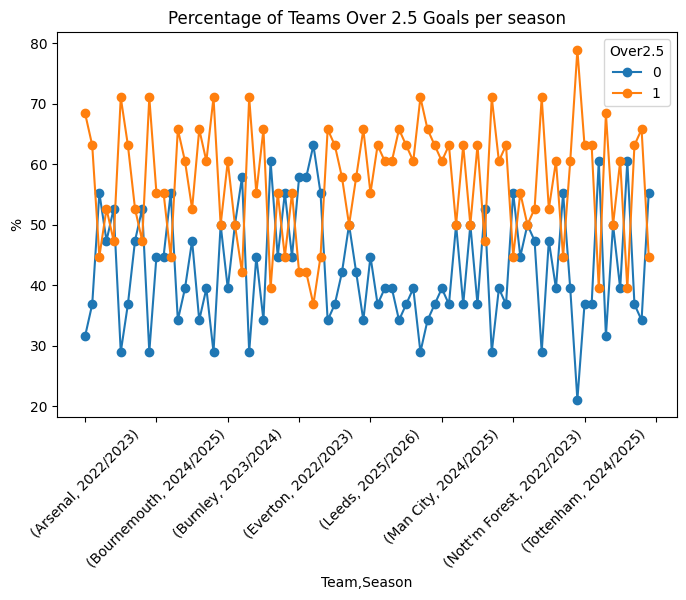

In [202]:
over_team_season.plot(
    marker="o",
    figsize=(8,5)
)

plt.title(
    "Percentage of Teams Over 2.5 Goals per season"
)
plt.xticks(rotation=45)
plt.ylabel("%")

plt.show()

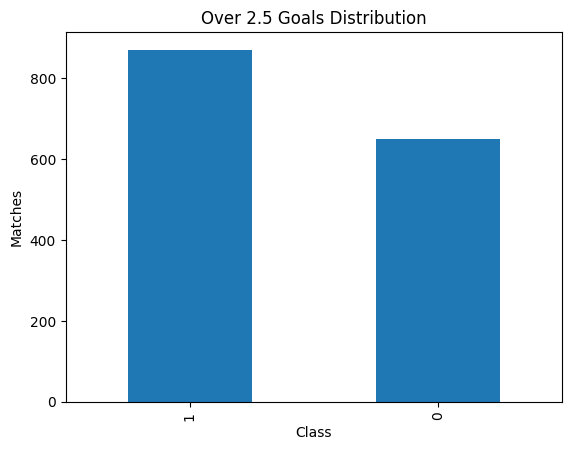

In [41]:
data["Over2.5"].value_counts().plot(
    kind="bar"
)

plt.title("Over 2.5 Goals Distribution")
plt.xlabel("Class")
plt.ylabel("Matches")

plt.show()

In [42]:
season_over25 = (
    data.groupby("Season")["Over2.5"]
      .mean()
      * 100
)

print(season_over25)

Season
2022/2023    52.631579
2023/2024    64.736842
2024/2025    56.578947
2025/2026    55.000000
Name: Over2.5, dtype: float64


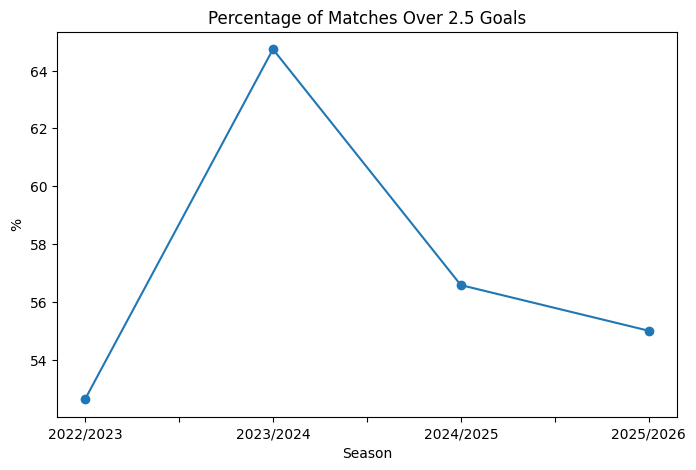

In [43]:
season_over25.plot(
    marker="o",
    figsize=(8,5)
)

plt.title(
    "Percentage of Matches Over 2.5 Goals"
)

plt.ylabel("%")

plt.show()

In [44]:
data.groupby("Season")["Over2.5"].value_counts()

Season     Over2.5
2022/2023  1          200
           0          180
2023/2024  1          246
           0          134
2024/2025  1          215
           0          165
2025/2026  1          209
           0          171
Name: count, dtype: int64

### ARE GOALS INCREASING OVER TIME?

In [334]:
goals_per_season = (data.groupby('Season')['TotalGoals'].mean().sort_index())
goals_per_season

Season
2022/2023    2.852632
2023/2024    3.278947
2024/2025    2.934211
2025/2026    2.750000
Name: TotalGoals, dtype: float64

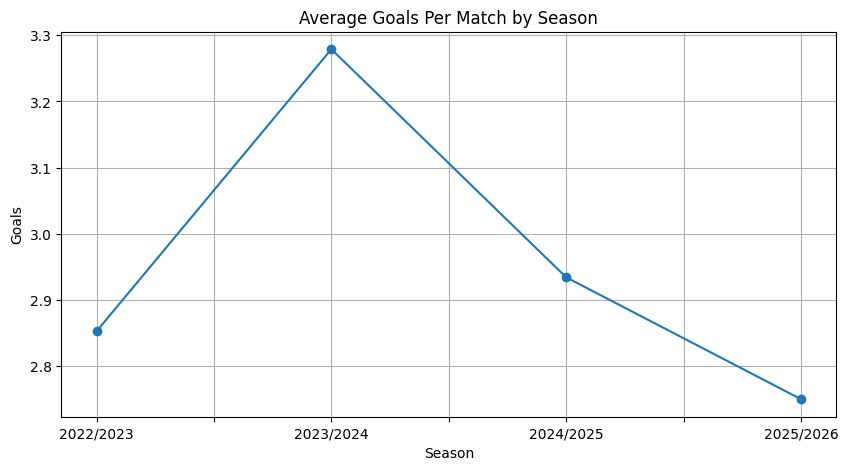

In [336]:
plt.figure(figsize=(10,5))

goals_per_season.plot(
    marker="o"
)
plt.title(
    "Average Goals Per Match by Season"
)
plt.ylabel("Goals")
plt.xlabel("Season")
plt.grid(True)

plt.show()

There is a spike in goals in the 2023/2024 season and there is a drop in 2024/2025 which further dropped in 2025/2026

##### GOALS GROWTH

In [340]:
goal_growth = (
    goals_per_season.pct_change()
    * 100
)
goal_growth

Season
2022/2023          NaN
2023/2024    14.944649
2024/2025   -10.513644
2025/2026    -6.278027
Name: TotalGoals, dtype: float64

### Team Analysis
Which teams are involved in high scoring matches?

In [46]:
home_goals = (data.groupby('HomeTeam')["TotalGoals"].mean())

away_goals = (data.groupby('AwayTeam')['TotalGoals'].mean())

team_goals_avg = (home_goals + away_goals) / 2
team_goals_avg.sort_values(ascending=False).head(10)

HomeTeam
Sheffield United    3.657895
Luton               3.605263
Tottenham           3.302632
Liverpool           3.236842
Man City            3.190789
Ipswich             3.105263
Newcastle           3.098684
Brighton            3.059211
Leicester           3.052632
Burnley             3.052632
Name: TotalGoals, dtype: float64

In [204]:
home_analysis = data[['HomeTeam', 'TotalGoals', 'Season']].rename(columns={'HomeTeam': 'Team'})
away_analysis = data[['AwayTeam', 'TotalGoals', 'Season']].rename(columns={'AwayTeam': 'Team'})
all_teams= pd.concat([home_analysis, away_analysis])

Checking to see the goal distribution percentage of teams across the seasons

In [215]:
all_teams_lys = pd.crosstab(
    index=[all_teams['Team'], all_teams['Season']], 
    columns=all_teams['TotalGoals'], 
    normalize='index'
) * 100

all_teams_lys.head(20)

TotalGoals                     0          1          2          3          4  \
Team        Season                                                             
Arsenal     2022/2023   2.631579  13.157895  15.789474  15.789474  21.052632   
            2023/2024   2.631579  18.421053  15.789474  21.052632  18.421053   
            2024/2025   5.263158  18.421053  31.578947  13.157895  21.052632   
            2025/2026   5.263158  23.684211  18.421053  28.947368   7.894737   
Aston Villa 2022/2023   2.631579  18.421053  31.578947  26.315789  15.789474   
            2023/2024   2.631579  10.526316  15.789474  13.157895  26.315789   
            2024/2025   2.631579  13.157895  21.052632  31.578947  21.052632   
            2025/2026   7.894737  18.421053  21.052632  23.684211  13.157895   
Bournemouth 2022/2023   5.263158  21.052632  26.315789  15.789474  10.526316   
            2023/2024   2.631579   7.894737  18.421053  28.947368  34.210526   
            2024/2025   5.263158  18.421053  21.052632  23.684211  18.421053   
            2025/2026  13.157895  10.526316  21.052632  13.157895  21.052632   
Brentford   2022/2023   7.894737  10.526316  36.842105  13.157895  18.421053   
            2023/2024   5.263158  13.157895  15.789474  23.684211  18.421053   
            2024/2025   7.894737   7.894737  23.684211  21.052632  15.789474   
            2025/2026  10.526316   7.894737  28.947368  15.789474  23.684211   
Brighton    2022/2023   5.263158  15.789474  13.157895  21.052632  18.421053   
            2023/2024   7.894737   5.263158  26.315789  21.052632  18.421053   
            2024/2025   5.263158   5.263158  18.421053  26.315789  26.315789   
            2025/2026   5.263158  13.157895  31.578947  31.578947  13.157895   

TotalGoals                     5          6         7         8         9  
Team        Season                                                         
Arsenal     2022/2023  21.052632  10.526316  0.000000  0.000000  0.000000  
            2023/2024  15.789474   5.263158  2.631579  0.000000  0.000000  
            2024/2025   0.000000   7.894737  2.631579  0.000000  0.000000  
            2025/2026  15.789474   0.000000  0.000000  0.000000  0.000000  
Aston Villa 2022/2023   0.000000   5.263158  0.000000  0.000000  0.000000  
            2023/2024  18.421053  10.526316  2.631579  0.000000  0.000000  
            2024/2025  10.526316   0.000000  0.000000  0.000000  0.000000  
            2025/2026   7.894737   2.631579  5.263158  0.000000  0.000000  
Bournemouth 2022/2023  15.789474   0.000000  2.631579  0.000000  2.631579  
            2023/2024   2.631579   0.000000  5.263158  0.000000  0.000000  
            2024/2025  10.526316   2.631579  0.000000  0.000000  0.000000  
            2025/2026  13.157895   5.263158  0.000000  2.631579  0.000000  
Brentford   2022/2023   5.263158   5.263158  2.631579  0.000000  0.000000  
            2023/2024  13.157895  10.526316  0.000000  0.000000  0.000000  
            2024/2025  10.526316   5.263158  5.263158  2.631579  0.000000  
            2025/2026   7.894737   2.631579  2.631579  0.000000  0.000000  
Brighton    2022/2023  10.526316  13.157895  2.631579  0.000000  0.000000  
            2023/2024  15.789474   2.631579  2.631579  0.000000  0.000000  
            2024/2025  10.526316   5.263158  2.631579  0.000000  0.000000  
            2025/2026   0.000000   2.631579  2.631579  0.000000  0.000000

In [47]:
# team_avg_df = team_goals_avg.reset_index()  # Convert Series to DataFrame
# team_avg_df.columns = ['HomeTeam', 'team_goals_avg']  # Rename columns

# # Merge with data to get Season
# result = data[['Season', 'HomeTeam']].drop_duplicates().merge(team_avg_df, on='HomeTeam')
# result.groupby('Season')['team_goals_avg'].mean().sort_values(ascending=False).head(10)

### CORNERS ANALYSIS

In [49]:
data['TotalCorners'] = data["HC"] + data["AC"]

In [50]:
data['TotalCorners'].describe()

count    1520.000000
mean       10.309868
std         3.393353
min         2.000000
25%         8.000000
50%        10.000000
75%        13.000000
max        21.000000
Name: TotalCorners, dtype: float64

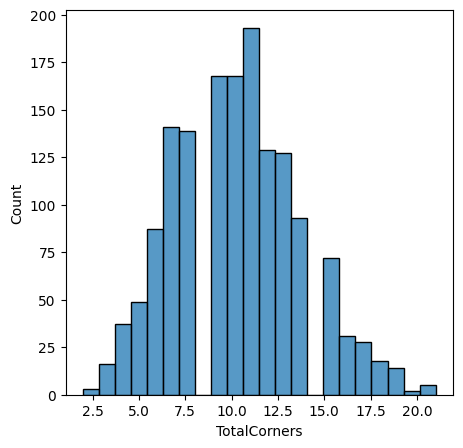

In [51]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['TotalCorners'])
plt.show()

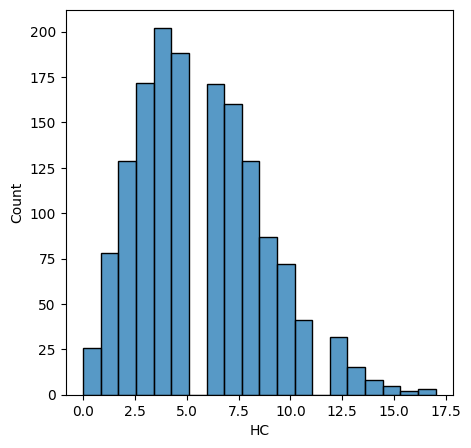

In [52]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['HC'])
plt.show()

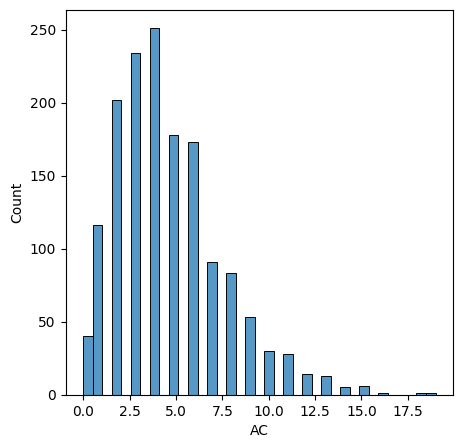

In [53]:
plt.figure(figsize=(5,5))
sns.histplot(data=data, x=data['AC'])
plt.show()

In [342]:
corners_per_season = (
    data.groupby("Season")["TotalCorners"]
        .mean()
        .sort_index()
)
corners_per_season

Season
2022/2023    10.107895
2023/2024    10.836842
2024/2025    10.297368
2025/2026     9.997368
Name: TotalCorners, dtype: float64

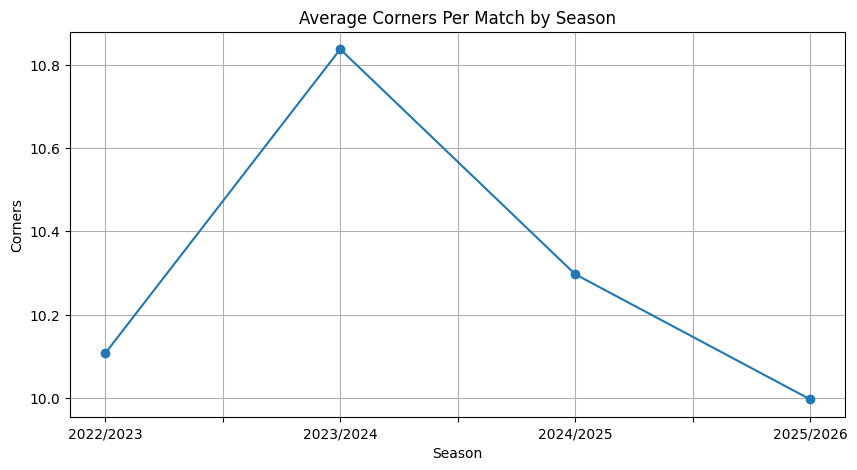

In [344]:
plt.figure(figsize=(10,5))

corners_per_season.plot(
    marker="o"
)

plt.title(
    "Average Corners Per Match by Season"
)

plt.ylabel("Corners")
plt.xlabel("Season")

plt.grid(True)

plt.show()

Corners dipped after the 2023/2024 season

In [349]:
x = np.arange(len(goals_per_season))
y = goals_per_season.values

slope, intercept, r, p, std_err = linregress(x, y)

print("Slope:", slope)
print("p-value:", p)

Slope: -0.06526315789473687
p-value: 0.6327195318057717


Slope is negative and very weak, which confirms that goals are decreasing across seasons.

A p-value greater than 0.05 suggests that the trend is not statistically significant.

#### High-corner teams?
##### Home corner advantage?

In [55]:
# Home corners earned
home_corners = (
    data.groupby("HomeTeam")["HC"]
      .sum()
      .reset_index()
      .rename(
          columns={
              "HomeTeam": "Team",
              "HC": "Corners"
          }
      )
)

# Away corners earned
away_corners = (
    data.groupby("AwayTeam")["AC"]
      .sum()
      .reset_index()
      .rename(
          columns={
              "AwayTeam": "Team",
              "AC": "Corners"
          }
      )
)

# Combine
team_corners = pd.concat(
    [home_corners, away_corners]
)

# Total corners per team
team_corners = (
    team_corners.groupby("Team")["Corners"]
                .sum()
                .sort_values(ascending=False)
)

print(team_corners.head(10))

Team
Man City       1022
Liverpool      1008
Arsenal         946
Newcastle       912
Tottenham       889
Chelsea         879
Aston Villa     829
Bournemouth     821
Brighton        813
Man United      803
Name: Corners, dtype: int64


In [56]:
home_corners_data = data[['HomeTeam', 'HC']].rename(columns={'HomeTeam': 'Team', 'HC': 'Corners'})
away_corners_data = data[['AwayTeam', 'AC']].rename(columns={'AwayTeam': 'Team', 'AC': 'Corners'})
all_corners = pd.concat([home_corners_data, away_corners_data])

# Now create a categorical variable for corner ranges (e.g., Over/Under 10.5 corners)
all_corners['CornerCategory'] = (all_corners['Corners'] > 10.5).map({True: 'Over10.5', False: 'Under10.5'})

# Calculate percentage of matches with over 10.5 corners by team
over_corner_season = pd.crosstab(all_corners['Team'], all_corners['CornerCategory'], normalize='index') * 100
print(over_corner_season.head(10))

CornerCategory   Over10.5   Under10.5
Team                                 
Arsenal         10.526316   89.473684
Aston Villa      7.236842   92.763158
Bournemouth      6.578947   93.421053
Brentford        1.315789   98.684211
Brighton         5.263158   94.736842
Burnley          1.315789   98.684211
Chelsea          7.236842   92.763158
Crystal Palace   3.289474   96.710526
Everton          0.000000  100.000000
Fulham           6.578947   93.421053


In [227]:
home_corners_data = data[['HomeTeam', 'HC', 'Season']].rename(columns={'HomeTeam': 'Team', 'HC': 'Corners'})
away_corners_data = data[['AwayTeam', 'AC', 'Season']].rename(columns={'AwayTeam': 'Team', 'AC': 'Corners'})
all_corners = pd.concat([home_corners_data, away_corners_data])

# Now create a categorical variable for corner ranges (e.g., Over/Under 10.5 corners)
all_corners['CornerCategory'] = (all_corners['Corners'] > 10.5).map({True: 'Over10.5', False: 'Under10.5'})

# Calculate percentage of matches with over 10.5 corners by team
over_corner_season = pd.crosstab(index=[all_corners['Team'], all_corners['Season']],columns=all_corners['CornerCategory'], normalize='index') * 100
over_corner_season.head(20)

CornerCategory          Over10.5   Under10.5
Team        Season                          
Arsenal     2022/2023   5.263158   94.736842
            2023/2024  13.157895   86.842105
            2024/2025  15.789474   84.210526
            2025/2026   7.894737   92.105263
Aston Villa 2022/2023   2.631579   97.368421
            2023/2024  10.526316   89.473684
            2024/2025  13.157895   86.842105
            2025/2026   2.631579   97.368421
Bournemouth 2022/2023   0.000000  100.000000
            2023/2024  13.157895   86.842105
            2024/2025   5.263158   94.736842
            2025/2026   7.894737   92.105263
Brentford   2022/2023   0.000000  100.000000
            2023/2024   5.263158   94.736842
            2024/2025   0.000000  100.000000
            2025/2026   0.000000  100.000000
Brighton    2022/2023  10.526316   89.473684
            2023/2024   5.263158   94.736842
            2024/2025   2.631579   97.368421
            2025/2026   2.631579   97.368421

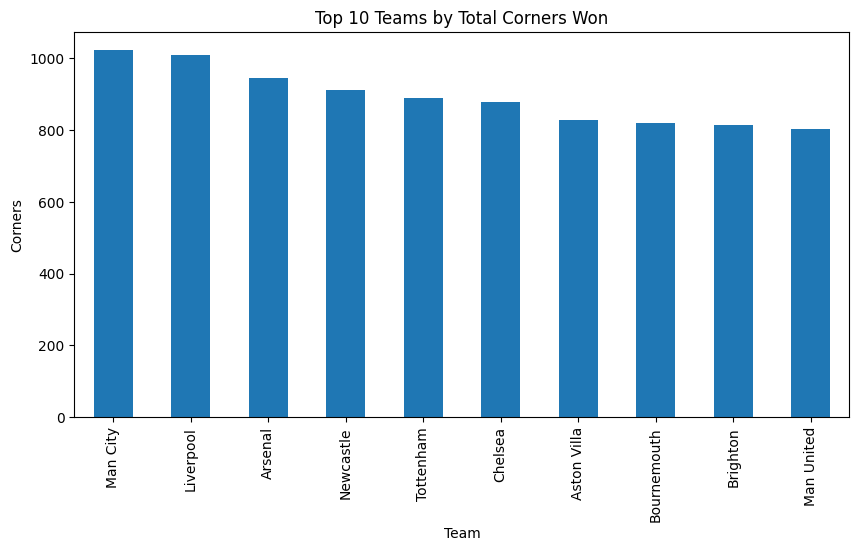

In [57]:
team_corners.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Teams by Total Corners Won")
plt.ylabel("Corners")
plt.show()

### AVERAGE CORNERS PER MATCHES

In [59]:
home_matches = data["HomeTeam"].value_counts()

away_matches = data["AwayTeam"].value_counts()

matches_played = (
    home_matches + away_matches
)

avg_corners = (
    team_corners / matches_played
).sort_values(
    ascending=False
)

avg_corners.head(10)

Man City       6.723684
Liverpool      6.631579
Arsenal        6.223684
Newcastle      6.000000
Tottenham      5.848684
Chelsea        5.782895
Aston Villa    5.453947
Bournemouth    5.401316
Luton          5.368421
Brighton       5.348684
dtype: float64

### Compare Home vs Away Corner Means

###### Do teams earn more corners when playing at home?

In [62]:
home_corner_mean = data['HC'].mean()
away_corner_mean = data['AC'].mean()

print("Home corner average is: ", home_corner_mean)
print("Away corner average is: ", away_corner_mean)

Home corner average is:  5.645394736842105
Away corner average is:  4.6644736842105265


From the averages above, it can be seen that home teams tend to slightly have an advantage over away teams in terms of corners.

Home teams earn approximately an  extra cornes per match.

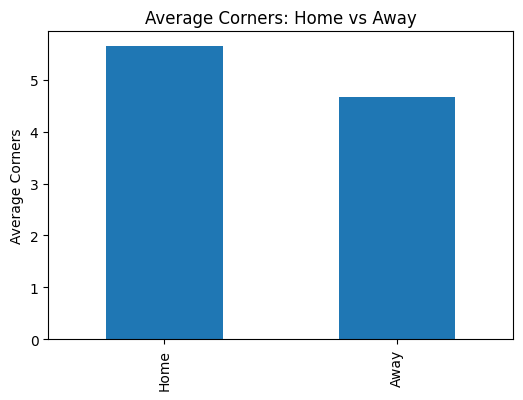

In [64]:
corner_means = pd.Series({
    "Home": data["HC"].mean(),
    "Away": data["AC"].mean()
})

corner_means.plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Corners: Home vs Away")
plt.ylabel("Average Corners")
plt.show()

### CHECKING FOR TEAM SPECIFIC HOME ADVANTAGE

In [66]:
home_avg = (
    data.groupby("HomeTeam")["HC"]
      .mean()
)

away_avg = (
    data.groupby("AwayTeam")["AC"]
      .mean()
)

corner_advantage = (
    home_avg - away_avg
).sort_values(
    ascending=False
)

corner_advantage.head(10)

HomeTeam
Luton          2.526316
Man United     1.750000
Leeds          1.710526
Tottenham      1.644737
Newcastle      1.526316
Brighton       1.460526
Man City       1.342105
Chelsea        1.223684
Arsenal        1.105263
Bournemouth    1.039474
dtype: float64

#### Is the difference between home and away corners statistically significant?

In [68]:
t_stat, p_value = ttest_ind(
    data["HC"],
    data["AC"]
)

print("p-value:", p_value)

p-value: 1.7635384527478308e-19


Based on the value from the p-value there is overwhelming evidence of a statistically significant relationship/effect.

### FOULS ANALYSIS

Which teams foul most?
Home vs away foul differences?

In [72]:
data['TotalFouls'] = data['HF'] + data['AF']

In [73]:
# Home fouls earned
home_fouls = (
    data.groupby("HomeTeam")["HF"]
      .sum()
      .reset_index()
      .rename(
          columns={
              "HomeTeam": "Team",
              "HF": "Fouls"
          }
      )
)

# Away fouls earned
away_fouls = (
    data.groupby("AwayTeam")["AF"]
      .sum()
      .reset_index()
      .rename(
          columns={
              "AwayTeam": "Team",
              "AF": "Fouls"
          }
      )
)

# Combine
team_fouls = pd.concat(
    [home_fouls, away_fouls]
)

team_fouls = (
    team_fouls.groupby("Team")["Fouls"]
              .sum()
              .sort_values(ascending=False)
)

print(team_fouls.head(10))

Team
Wolves            1914
Bournemouth       1868
Tottenham         1757
Brighton          1731
Crystal Palace    1717
Chelsea           1704
Everton           1688
Liverpool         1680
Nott'm Forest     1671
Fulham            1641
Name: Fouls, dtype: int64


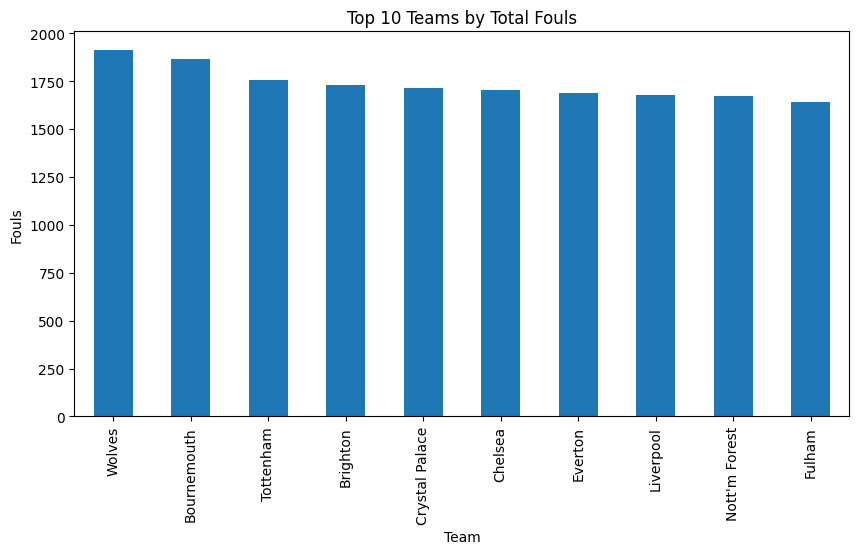

In [74]:
team_fouls.head(10).plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Teams by Total Fouls")
plt.ylabel("Fouls")
plt.show()

AVERAGE FOULS

In [76]:
home_matches = data["HomeTeam"].value_counts()

away_matches = data["AwayTeam"].value_counts()

matches_played = (
    home_matches + away_matches
)

avg_fouls = (team_fouls/ matches_played).sort_values(ascending=False)
avg_fouls.head(10)

Wolves            12.592105
Bournemouth       12.289474
Southampton       11.697368
Luton             11.657895
Tottenham         11.559211
Brighton          11.388158
Ipswich           11.315789
Crystal Palace    11.296053
Leeds             11.236842
Chelsea           11.210526
dtype: float64

In [77]:
home_foul_mean = data["HF"].mean()

away_foul_mean = data["AF"].mean()

print("Home Fouls:", home_foul_mean)
print("Away Fouls:", away_foul_mean)

Home Fouls: 10.696052631578947
Away Fouls: 11.136184210526316


In [78]:
home_avg = data.groupby('HomeTeam')['HF'].mean()

away_avg = data.groupby("AwayTeam")['AF'].mean()

foul_difference = (away_avg - home_avg).sort_values(ascending=False)
foul_difference.head(10)

AwayTeam
Ipswich          2.210526
Southampton      1.657895
Brentford        1.486842
Burnley          1.184211
Fulham           1.039474
Everton          1.000000
Chelsea          0.894737
Sunderland       0.789474
Wolves           0.684211
Nott'm Forest    0.618421
dtype: float64

In [79]:
t_stat, p_value = ttest_ind(
    data["HF"],
    data["AF"]
)

print("p-value:", p_value)

p-value: 0.00045763844225843865


The difference between home and away
fouls is statistically significant.

#### AGGRESSION INDEX

In [82]:
team_aggression = (
    team_fouls / matches_played
)
scaler = MinMaxScaler()

aggression_score = scaler.fit_transform(
    team_aggression.values.reshape(-1,1)
)

### CORRELATION ANALYSIS

In [230]:
numerical_cols = [
    "FTHG",  # Home Goals
    "FTAG",  # Away Goals
    "HS",    # Home Shots
    "AS",    # Away Shots
    "HST",   # Home Shots on Target
    "AST",   # Away Shots on Target
    "HC",    # Home Corners
    "AC",    # Away Corners
    "HF",    # Home Fouls
    "AF",    # Away Fouls
    "HY",    # Home Yellow Cards
    "AY",    # Away Yellow Cards
    "HR",    # Home Red Cards
    "AR"     # Away Red Cards
]

In [232]:
corr_matrix = data[numerical_cols].corr()

corr_matrix

,FTHG,FTAG,HS,AS,HST,AST,HC,AC,HF,AF,HY,AY,HR,AR
FTHG,1.000000,-0.113243,0.305510,-0.165584,0.582124,-0.155194,0.058922,-0.090673,-0.068895,0.035167,-0.080126,0.051811,-0.090709,0.036593
FTAG,-0.113243,1.000000,-0.105684,0.304425,-0.104058,0.584465,-0.047417,0.064372,-0.009915,-0.105012,0.055179,-0.090899,0.120481,-0.061581
HS,0.305510,-0.105684,1.000000,-0.387323,0.688558,-0.250991,0.545239,-0.377290,-0.086673,-0.002982,-0.102202,0.091219,-0.120439,0.129384
AS,-0.165584,0.304425,-0.387323,1.000000,-0.244684,0.674430,-0.336114,0.556592,0.014199,-0.144964,0.108435,-0.130006,0.095246,-0.097298
HST,0.582124,-0.104058,0.688558,-0.244684,1.000000,-0.196166,0.318482,-0.222632,-0.057101,0.001280,-0.070327,0.092610,-0.105546,0.079793
AST,-0.155194,0.584465,-0.250991,0.674430,-0.196166,1.000000,-0.193659,0.327934,-0.005553,-0.119428,0.071962,-0.110154,0.113948,-0.054431
HC,0.058922,-0.047417,0.545239,-0.336114,0.318482,-0.193659,1.000000,-0.350363,-0.086199,0.008875,-0.055959,0.097946,-0.095344,0.090163
AC,-0.090673,0.064372,-0.377290,0.556592,-0.222632,0.327934,-0.350363,1.000000,-0.003161,-0.129641,0.074477,-0.073851,0.078099,-0.042597
HF,-0.068895,-0.009915,-0.086673,0.014199,-0.057101,-0.005553,-0.086199,-0.003161,1.000000,0.105334,0.341826,0.095552,0.064687,0.055500
AF,0.035167,-0.105012,-0.002982,-0.144964,0.001280,-0.119428,0.008875,-0.129641,0.105334,1.000000,0.084342,0.384406,0.039107,0.062241


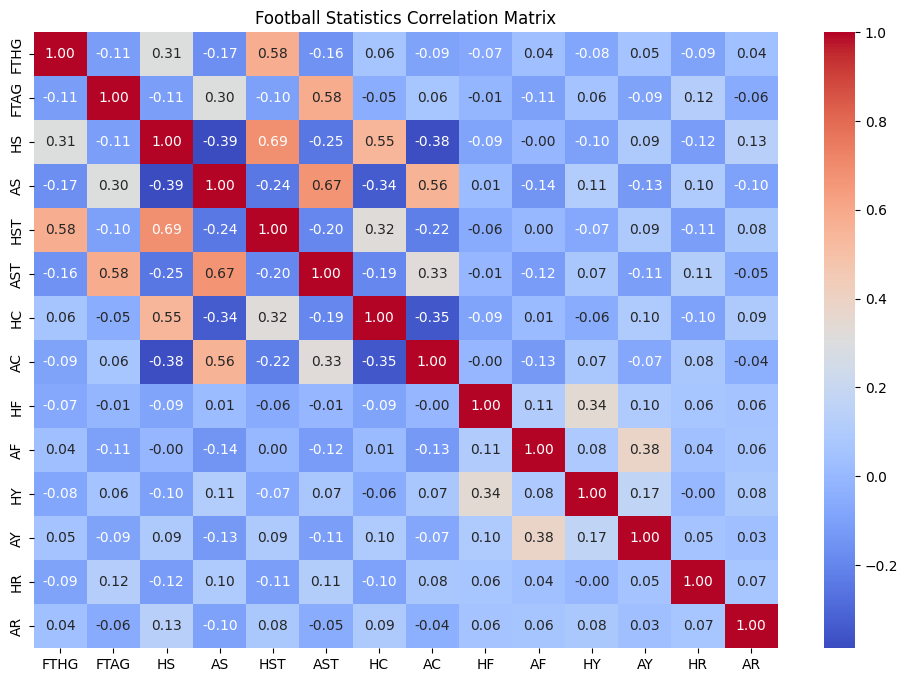

In [235]:
plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Football Statistics Correlation Matrix")
plt.show()

#### Do Shots Correlate with Goals?

##### Home Teams

In [239]:
data["HS"].corr(data["FTHG"])

0.305509569482769

There is a weak correlation between Home shots and Full time Home goals

In [241]:
data["HST"].corr(data["FTHG"])

0.5821242424592125

There is a moderate correlation between Home shots on target and Full time home goals

##### Away Teams

In [250]:
data["AS"].corr(data["FTAG"])

0.3044245403159729

There is a weak correlation between Away shots and Full time Away goals

In [252]:
data["AST"].corr(data["FTAG"])

0.5844649481542599

There is a moderate correlation between Home shots on target and Full time home goals

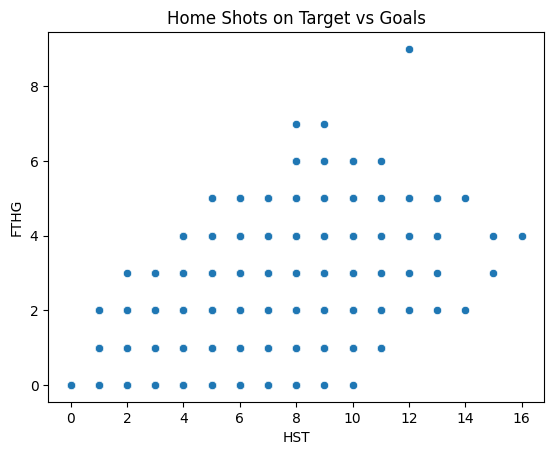

In [259]:
sns.scatterplot(
    data=data,
    x="HST",
    y="FTHG"
)
plt.title(
    "Home Shots on Target vs Goals"
)
plt.show()

#### Do Corners Correlate with Goals?

##### Home teams

In [265]:
data["HC"].corr(data["FTHG"])

0.05892185953748192

There is a very weak correlation between home corners and the full time home goals

##### Away teams

In [267]:
data["AC"].corr(data["FTAG"])

0.06437165220150778

There is a very weak correlation between away corners and the full time away goals but a bit higher than home teams corners correlation with full time goals

Teams earning more corners
tend to score more goals,
but the relationship is weaker
than shots on target.

Corners create chances,
but not every corner
becomes a goal.

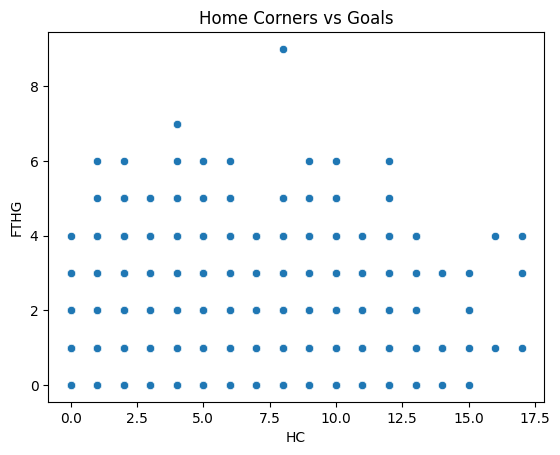

In [279]:
sns.scatterplot(
    data=data,
    x="HC",
    y="FTHG"
)
plt.title(
    "Home Corners vs Goals"
)
plt.show()

#### Do Fouls Correlate with Cards?

##### Home team

In [284]:
data["HF"].corr(data["HY"])

0.3418255100986082

##### Away team

In [287]:
data["AF"].corr(data["AY"])

0.38440596781882747

There is a weak correlation between teams committing fouls and receiving yellow cards

#### FOULS AND RED CARDS

In [292]:
data["HF"].corr(data["HR"])

0.06468687988949601

In [294]:
data["AF"].corr(data["AR"])

0.06224084890776978

The correlations show that there is a very weak positive correlation between teams committing fouls and receiving red cards

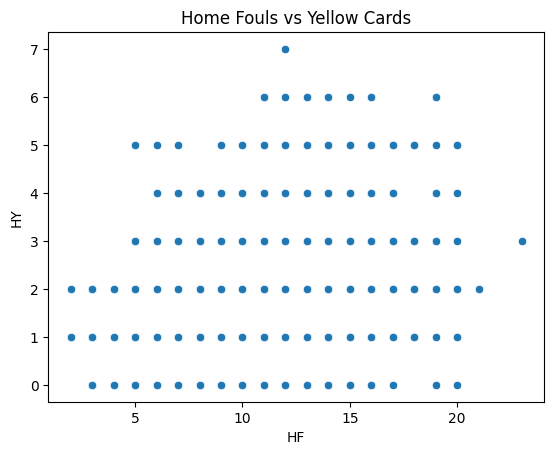

In [300]:
sns.scatterplot(
    data=data,
    x="HF",
    y="HY"
)
plt.title(
    "Home Fouls vs Yellow Cards"
)
plt.show()

### CREATING NEW FEATURES

In [307]:
data["TotalShotsOnTarget"] = (
    data["HST"] + data["AST"]
)

In [309]:
data["TotalCorners"] = (
    data["HC"] + data["AC"]
)

In [311]:
data["TotalFouls"] = (
    data["HF"] + data["AF"]
)

In [313]:
data["TotalYellowCards"] = (
    data["HY"] + data["AY"]
)

#### Checking for correlation between features created

In [322]:
data["TotalShotsOnTarget"].corr(
    data["TotalGoals"]
)

0.5374541247431597

There is a moderate relationship between total shots on target and total goals

In [329]:
data["TotalCorners"].corr(
    data["TotalGoals"]
)

-0.010251158988530224

There is very weak negative correlation between total corners and total goals, which suggests that there is no relationship between total corners and total goals

In [326]:
data["TotalFouls"].corr(
    data["TotalYellowCards"]
)

0.39968003183594414

There is a weak relationship between total fouls committed by teams and total yellow cards received by teams committing fouls